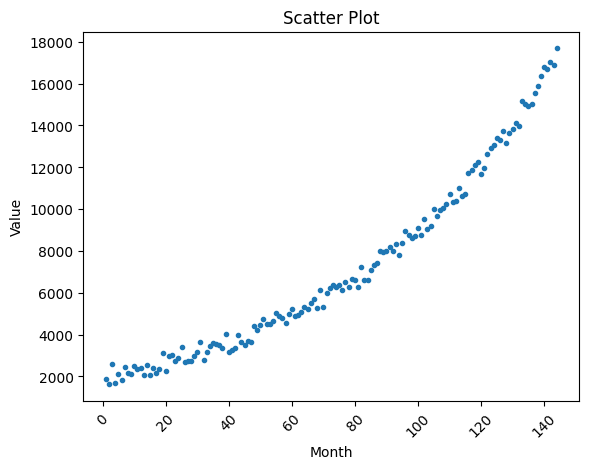

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_excel('aol_data.xlsx', engine='openpyxl')

x = range(1, len(df.columns) + 1)
y = df.iloc[0].values

plt.plot(x, y, marker = 'o', linestyle = 'none', markersize = 3)

plt.xlabel('Month')
plt.ylabel('Value')
plt.title('Scatter Plot')

plt.xticks(rotation=45)
plt.show()


Polynomial Degree 1 :
y = 100.676x + -141.036x
Coefficients for degree 1: [ 100.67568322 -141.03564491]


Polynomial Degree 2 :
y = 0.706x^2 + -1.68x + 2349.63x
Coefficients for degree 2: [ 7.05904176e-01 -1.68042233e+00  2.34962959e+03]


Polynomial Degree 3 :
y = 0.004x^3 + -0.134x^2 + 47.224x + 1748.507x
Coefficients for degree 3: [ 3.86326992e-03 -1.34357030e-01  4.72235525e+01  1.74850672e+03]




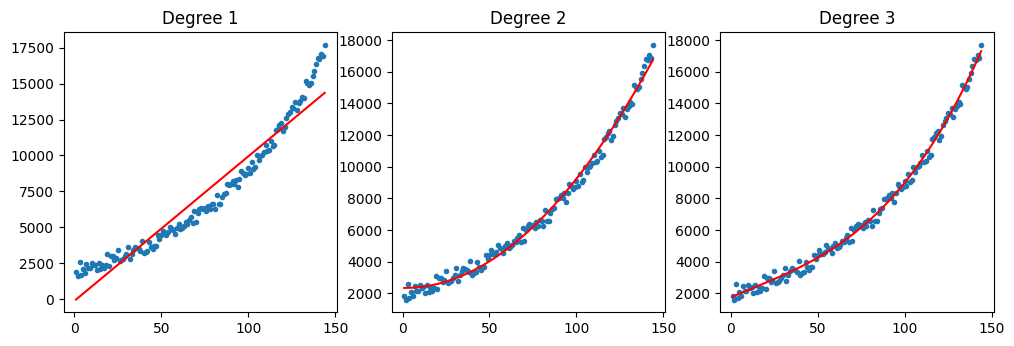

In [2]:
x = np.array(x)
y = np.array(y)

plt.figure(figsize=(12, 8))

for i in range (1, 4):
    plt.subplot(2, 3, i)
    plt.plot(x, y, '.')

    coef = np.polyfit(x, y, i)

    plt.plot(x, np.polyval(coef, x), '-r')
    plt.title(f"Polynomial Regression {i}")

    threshold = 1e-3

    equation = "y = " + " + ".join([
        f"{round(c, 3)}x^{i-j}"if abs(c) > threshold and i-j > 1 else
        (f"{round(c, 3)}x" if abs(c) > threshold and i-j == 1 else
        (f"{round(c, 3)}x" if abs(c) > threshold else "0"))
        for j, c in enumerate(coef)
    ])

    plt.title(f"Degree {i}")
    print(f"Polynomial Degree {i} :\n{equation}")
    print(f"Coefficients for degree {i}:", coef)
    print("\n")

R² Deg 3 = 0.994


<function matplotlib.pyplot.show(close=None, block=None)>

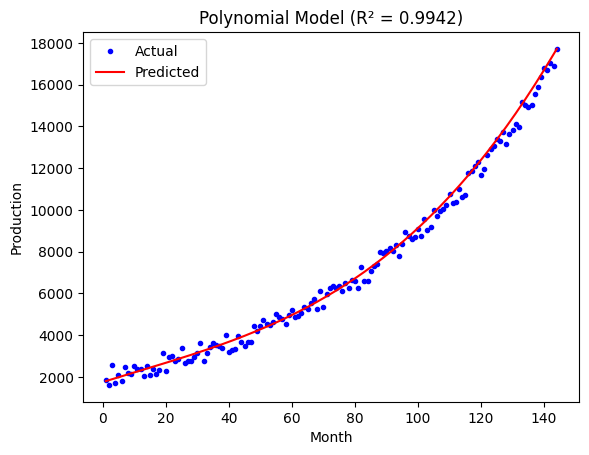

In [3]:
from sklearn.metrics import r2_score

def predict3(x):
    return 0.004*x**3 - 0.134*x**2 + 47.224*x + 1748.507

yPred3 = predict3(x)
r2_3 = r2_score(y, yPred3)

print(f"R² Deg 3 = {r2_3:.3f}")

plt.plot(x, y, '.b', label = "Actual")
plt.plot(x, yPred3, '-r', label = "Predicted")

plt.legend()
plt.title(f"Polynomial Model (R² = {r2_3:.4f})")
plt.xlabel("Month")
plt.ylabel("Production")
plt.show